# Gerçek Zamanlı Meme Ultrason Segmentasyonu — Veri Analizi (EDA)

**Veri seti:** BUSI (Dataset_BUSI_with_GT) — benign / malignant / normal

Bu notebook eğitim öncesi tüm veri kararlarının dayanağını üretir:

1. Envanter ve dosya bütünlüğü (görüntü–maske eşleşmesi, çoklu maskeler, anomaliler)
2. Vaka başına istatistik tablosu (çözünürlük, lezyon alanı, bileşen sayısı, kontrast)
3. Dağılım grafikleri (sınıf, çözünürlük, lezyon morfolojisi, yoğunluk)
4. Yinelenen / yakın-kopya görüntü tespiti — split sızıntısı riski
5. **Gerçek zamanlı çözünürlük analizi** — hangi girdi boyutunda lezyon kaç piksele iniyor
6. Örnek vaka görselleri + özet rapor

Çıktılar: `Drive/real_time_segmentasyon/eda/` (kalıcı) + `/content/outputs/eda/` (yerel ayna).

In [1]:
from google.colab import drive
drive.mount('/content/drive')

import os, re, json, shutil, hashlib
from pathlib import Path
from collections import defaultdict

import numpy as np
import pandas as pd
import cv2
import matplotlib.pyplot as plt

DATA_ROOT = '/content/drive/MyDrive/real_time_segmentasyon/Dataset_BUSI_with_GT'
DRIVE_DIR = '/content/drive/MyDrive/real_time_segmentasyon/eda'
LOCAL_DIR = '/content/outputs/eda'
FIG_DIR = f'{DRIVE_DIR}/figurler'

for d in [DRIVE_DIR, LOCAL_DIR, FIG_DIR]:
    Path(d).mkdir(parents=True, exist_ok=True)

CLASSES = ['benign', 'malignant', 'normal']
CLASS_COLORS = {'benign': 'tab:green', 'malignant': 'tab:red', 'normal': 'tab:blue'}
SEED = 42
plt.rcParams['figure.dpi'] = 110


def mirror_to_local(drive_path):
    # Drive'daki ciktinin yerel kopyasi, oturum kopmalarina karsi
    dst = Path(LOCAL_DIR) / Path(drive_path).name
    shutil.copy2(drive_path, dst)
    return str(dst)


def savefig(path):
    plt.savefig(path, bbox_inches='tight')
    mirror_to_local(path)


print('Veri kok :', DATA_ROOT)
print('Mevcut mu:', os.path.isdir(DATA_ROOT))
if os.path.isdir(DATA_ROOT):
    print('Alt klasorler:', sorted(os.listdir(DATA_ROOT)))

Mounted at /content/drive
Veri kok : /content/drive/MyDrive/real_time_segmentasyon/Dataset_BUSI_with_GT
Mevcut mu: True
Alt klasorler: ['benign', 'malignant', 'normal']


## 1. Envanter ve dosya bütünlüğü

BUSI dosya şeması: `<sinif> (<n>).png` görüntü, `<sinif> (<n>)_mask.png` maske. Bazı vakalarda birden fazla lezyon için `_mask_1.png`, `_mask_2.png` ek maskeleri var. Bu hücre eşleşmeyi kurar, maskesiz görüntü / görüntüsüz maske gibi anomalileri raporlar.

In [2]:
MASK_RE = re.compile(r'^(?P<stem>.+?)_mask(?:_(?P<idx>\d+))?\.png$', re.IGNORECASE)


def build_case_index(data_root):
    cases, anomalies = [], []
    for cls in CLASSES:
        cdir = Path(data_root) / cls
        images, masks = {}, defaultdict(list)
        for p in sorted(cdir.glob('*.png')):
            m = MASK_RE.match(p.name)
            if m:
                masks[m.group('stem')].append(p.name)
            else:
                images[p.stem] = p.name
        for stem, fname in sorted(images.items()):
            # _mask.png once, _mask_1.png sonra gelsin diye uzunluga gore siralanir
            mlist = sorted(masks.pop(stem, []), key=lambda s: (len(s), s))
            if not mlist:
                anomalies.append((cls, stem, 'maske dosyasi yok'))
                continue
            cases.append(dict(case_id=f'{cls}/{stem}', cls=cls,
                              image=str(cdir / fname),
                              masks=[str(cdir / x) for x in mlist]))
        for stem in masks:
            anomalies.append((cls, stem, 'goruntusu olmayan maske'))
    return cases, anomalies


cases, anomalies = build_case_index(DATA_ROOT)

print('Toplam vaka:', len(cases))
print(pd.Series([c['cls'] for c in cases]).value_counts().reindex(CLASSES).to_string())
print()
multi = [c for c in cases if len(c['masks']) > 1]
print('Coklu maske dosyasi olan vaka:', len(multi))
for c in multi[:10]:
    print('   ', c['case_id'], '->', len(c['masks']), 'maske')
print()
print('Anomali sayisi:', len(anomalies))
for a in anomalies[:20]:
    print('   ', a)

Toplam vaka: 780
benign       437
malignant    210
normal       133

Coklu maske dosyasi olan vaka: 17
    benign/benign (100) -> 2 maske
    benign/benign (163) -> 2 maske
    benign/benign (173) -> 2 maske
    benign/benign (181) -> 2 maske
    benign/benign (195) -> 3 maske
    benign/benign (25) -> 2 maske
    benign/benign (315) -> 2 maske
    benign/benign (346) -> 2 maske
    benign/benign (4) -> 2 maske
    benign/benign (424) -> 2 maske

Anomali sayisi: 0


## 2. Vaka başına istatistik tablosu

Çoklu maskeler **birleşim (union)** ile tek binary maskeye indirgenir — aynı görüntüdeki ayrı lezyonlar tek foreground sınıfı altında toplanır. Hesaplanan alanlar: çözünürlük, lezyon piksel/oran, bağlantılı bileşen, bbox, merkez konumu, lezyon-arkaplan kontrastı ve yakın-kopya tespiti için algısal hash.

In [3]:
def read_gray(path):
    im = cv2.imread(path, cv2.IMREAD_UNCHANGED)
    if im is None:
        raise FileNotFoundError(path)
    ch = 1 if im.ndim == 2 else im.shape[2]
    if im.ndim == 3:
        im = cv2.cvtColor(im[:, :, :3], cv2.COLOR_BGR2GRAY)
    if im.dtype != np.uint8:
        im = cv2.normalize(im, None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)
    return im, ch


def dhash64(gray, size=8):
    # yatay gradyan isaretinden 64 bit algisal hash
    r = cv2.resize(gray, (size + 1, size), interpolation=cv2.INTER_AREA)
    bits = (r[:, 1:] > r[:, :-1]).flatten()
    return int(''.join('1' if b else '0' for b in bits), 2)


def merge_masks(paths, shape):
    out = np.zeros(shape, np.uint8)
    vals, resized = set(), False
    for p in paths:
        m, _ = read_gray(p)
        vals.update(np.unique(m).tolist())
        if m.shape != shape:
            m = cv2.resize(m, (shape[1], shape[0]), interpolation=cv2.INTER_NEAREST)
            resized = True
        out = np.maximum(out, (m > 127).astype(np.uint8))
    return out, sorted(vals), resized


# kopya dogrulamasi ikinci bir tam okuma gerektirmesin diye kucuk kopyalar burada tutulur
N = len(cases)
thumbs = np.zeros((N, 128 * 128), np.float32)   # z-normalize, korelasyon icin
mthumbs = np.zeros((N, 64, 64), np.uint8)       # maske, IoU icin

rows = []
for i, c in enumerate(cases):
    img, ch = read_gray(c['image'])
    h, w = img.shape
    mask, mvals, mresized = merge_masks(c['masks'], img.shape)
    area = int(mask.sum())
    n_lab, _, st, _ = cv2.connectedComponentsWithStats(mask, connectivity=8)
    comps = st[1:, cv2.CC_STAT_AREA] if n_lab > 1 else np.array([], int)

    t = cv2.resize(img, (128, 128), interpolation=cv2.INTER_AREA).astype(np.float32).ravel()
    thumbs[i] = (t - t.mean()) / (t.std() + 1e-6)
    mthumbs[i] = cv2.resize(mask, (64, 64), interpolation=cv2.INTER_NEAREST)

    if area > 0:
        ys, xs = np.nonzero(mask)
        bx0, bx1, by0, by1 = int(xs.min()), int(xs.max()), int(ys.min()), int(ys.max())
        bw, bh = bx1 - bx0 + 1, by1 - by0 + 1
        cx, cy = (bx0 + bx1) / 2 / w, (by0 + by1) / 2 / h
        les_mean = float(img[mask == 1].mean())
        bg = img[mask == 0]
    else:
        bw = bh = 0
        cx = cy = np.nan
        les_mean = np.nan
        bg = img.reshape(-1)
    bg_mean, bg_std = float(bg.mean()), float(bg.std())

    rows.append(dict(
        case_id=c['case_id'], cls=c['cls'], n_mask_files=len(c['masks']),
        height=h, width=w, channels=ch, aspect=w / h, n_pixels=h * w,
        mask_resized=mresized, mask_vals=str(mvals[:6]),
        lesion_px=area, lesion_ratio=area / (h * w),
        n_components=int(n_lab - 1),
        largest_comp_px=int(comps.max()) if comps.size else 0,
        smallest_comp_px=int(comps.min()) if comps.size else 0,
        bbox_w=int(bw), bbox_h=int(bh),
        bbox_fill=(area / (bw * bh)) if area > 0 else np.nan,
        eq_diam=float(2 * np.sqrt(area / np.pi)),
        eq_diam_rel=float(2 * np.sqrt(area / np.pi) / max(h, w)) if area > 0 else np.nan,
        center_x=cx, center_y=cy,
        img_mean=float(img.mean()), img_std=float(img.std()),
        lesion_mean=les_mean, bg_mean=bg_mean,
        contrast=((les_mean - bg_mean) / (bg_std + 1e-6)) if area > 0 else np.nan,
        dhash=dhash64(img),
    ))

df = pd.DataFrame(rows)
print('Tablo:', df.shape)
df.head()

Tablo: (780, 28)


,case_id,cls,n_mask_files,height,width,channels,aspect,n_pixels,mask_resized,mask_vals,...,eq_diam,eq_diam_rel,center_x,center_y,img_mean,img_std,lesion_mean,bg_mean,contrast,dhash
0,benign/benign (1),benign,1,471,562,3,1.193206,264702,False,"[0, 255]",...,35.395871,0.062982,0.556940,0.311040,132.375146,58.393189,73.695122,132.594097,-1.009465,15282554755480875256
1,benign/benign (10),benign,1,585,683,3,1.167521,399555,False,"[0, 255]",...,204.725424,0.299744,0.187408,0.282051,103.240733,58.324293,9.815025,111.628832,-1.917785,4859783324841483022
2,benign/benign (100),benign,2,473,323,3,0.682875,152779,False,"[0, 255]",...,112.899961,0.238689,0.504644,0.346723,90.107849,67.727781,68.890820,91.595603,-0.328276,11452154259895684623
3,benign/benign (101),benign,1,473,563,3,1.190275,266299,False,"[0, 255]",...,72.839475,0.129377,0.865009,0.416490,103.225690,57.230160,70.040077,103.753227,-0.587363,1557637808471357239
4,benign/benign (102),benign,1,610,634,3,1.039344,386740,False,"[0, 255]",...,154.949921,0.244401,0.562303,0.188525,54.390260,37.923081,14.296283,56.445402,-1.121875,10774447400925759255


In [4]:
STATS_XLSX = f'{DRIVE_DIR}/eda_vaka_istatistikleri.xlsx'
df.drop(columns=['dhash']).to_excel(STATS_XLSX, index=False)
mirror_to_local(STATS_XLSX)

print('=== Saglik kontrolu ===')
print('Kanal sayilari             :', df['channels'].value_counts().to_dict())
print('Maske-goruntu boyutu farkli:', int(df['mask_resized'].sum()))
print('Bos maskeli vaka           :', int((df['lesion_px'] == 0).sum()))
ok_vals = {'[0, 255]', '[0]', '[255]'}
print('Binary olmayan maske degeri:', int((~df['mask_vals'].isin(ok_vals)).sum()))
print('Gorulen maske deger setleri:', df['mask_vals'].value_counts().to_dict())
print()
print('=== Cozunurluk ===')
print(df[['height', 'width']].describe().loc[['min', '25%', '50%', '75%', 'max']].to_string())
print('Benzersiz cozunurluk sayisi:', df.groupby(['height', 'width']).ngroups)
print('En sik 5:', df.groupby(['height', 'width']).size().sort_values(ascending=False).head(5).to_dict())
print()
print('=== Lezyon alan orani (%, sadece lezyonlu vakalar) ===')
les = df[df['lesion_px'] > 0]
tbl = les.groupby('cls')['lesion_ratio'].agg(['count', 'mean', 'median', 'min', 'max'])
for col in ['mean', 'median', 'min', 'max']:
    tbl[col] = (tbl[col] * 100).round(3)
print(tbl.to_string())
print()
print('=== Bagli bilesen sayisi (lezyon adedi) ===')
print(pd.crosstab(df['cls'], df['n_components']).to_string())

=== Saglik kontrolu ===
Kanal sayilari             : {3: 780}
Maske-goruntu boyutu farkli: 0
Bos maskeli vaka           : 133
Binary olmayan maske degeri: 0
Gorulen maske deger setleri: {'[0, 255]': 647, '[0]': 133}

=== Cozunurluk ===
     height   width
min   310.0   190.0
25%   465.0   554.0
50%   474.0   564.0
75%   574.0   713.5
max   719.0  1048.0
Benzersiz cozunurluk sayisi: 639
En sik 5: {(465, 557): 6, (470, 562): 5, (467, 556): 4, (587, 775): 4, (467, 558): 4}

=== Lezyon alan orani (%, sadece lezyonlu vakalar) ===
           count    mean  median    min     max
cls                                            
benign       437   6.885   3.790  0.281  51.297
malignant    210  14.744  12.061  0.506  56.292

=== Bagli bilesen sayisi (lezyon adedi) ===
n_components    0    1   2  3  4
cls                             
benign          0  413  22  1  1
malignant       0  200   7  3  0
normal        133    0   0  0  0


## 3. Envanter grafikleri

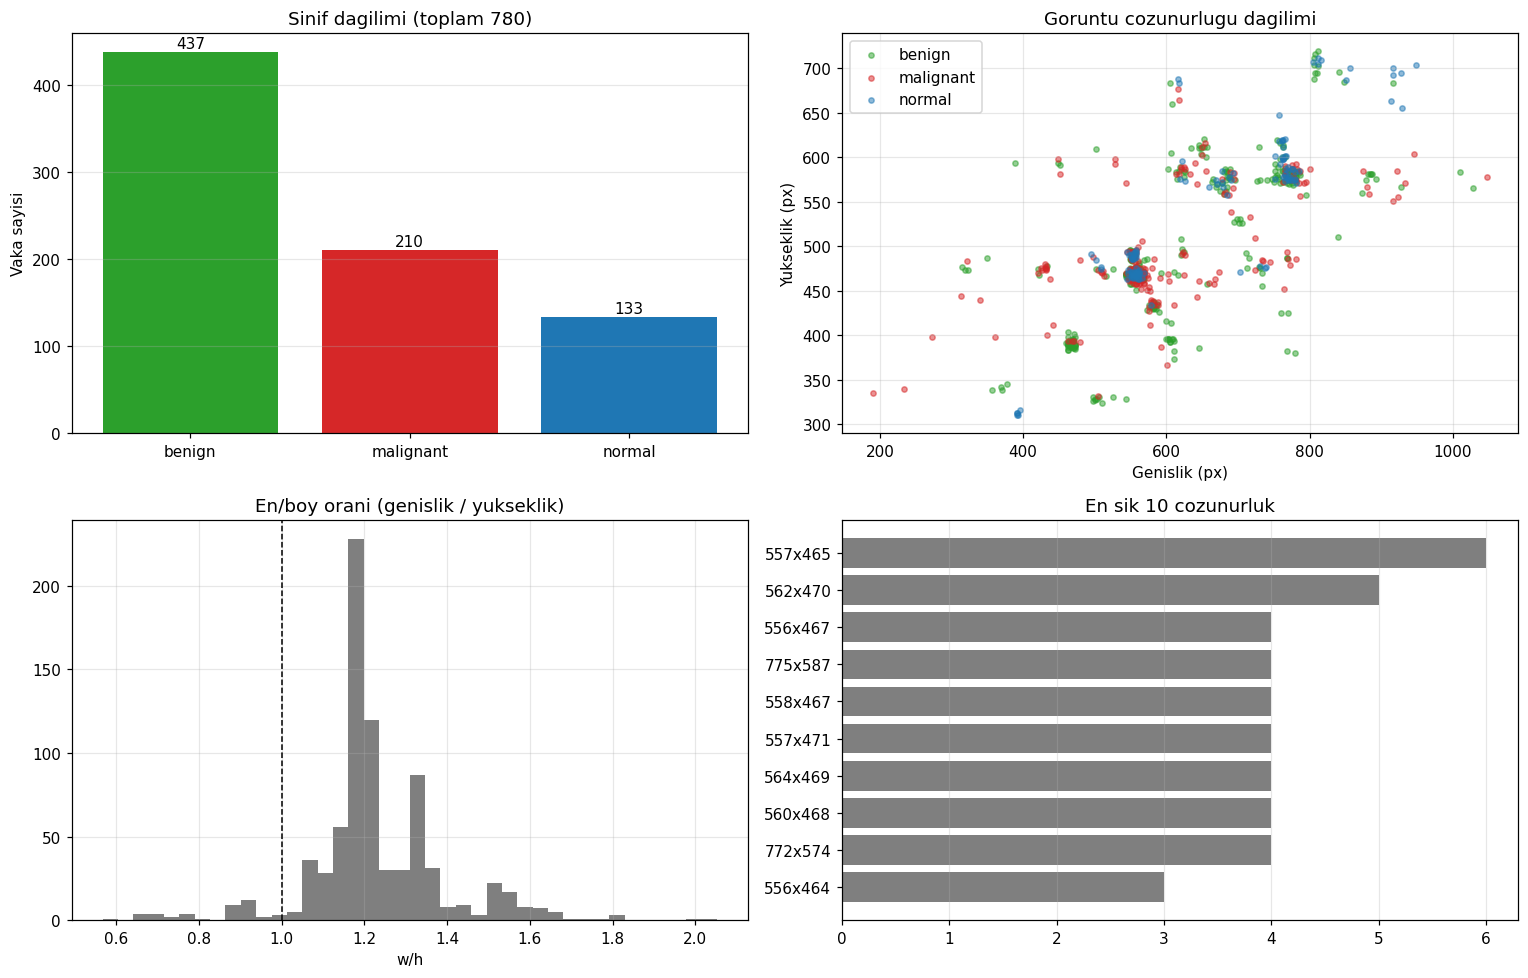

In [5]:
fig, ax = plt.subplots(2, 2, figsize=(14, 9))

vc = df['cls'].value_counts().reindex(CLASSES)
ax[0, 0].bar(vc.index, vc.values, color=[CLASS_COLORS[c] for c in vc.index])
for i, v in enumerate(vc.values):
    ax[0, 0].text(i, v + 5, str(v), ha='center')
ax[0, 0].set_title(f'Sinif dagilimi (toplam {len(df)})')
ax[0, 0].set_ylabel('Vaka sayisi'); ax[0, 0].grid(alpha=0.3, axis='y')

for c in CLASSES:
    s = df[df['cls'] == c]
    ax[0, 1].scatter(s['width'], s['height'], s=12, alpha=0.5, label=c, color=CLASS_COLORS[c])
ax[0, 1].set_xlabel('Genislik (px)'); ax[0, 1].set_ylabel('Yukseklik (px)')
ax[0, 1].set_title('Goruntu cozunurlugu dagilimi'); ax[0, 1].legend(); ax[0, 1].grid(alpha=0.3)

ax[1, 0].hist(df['aspect'], bins=40, color='tab:gray')
ax[1, 0].axvline(1.0, color='k', ls='--', lw=1)
ax[1, 0].set_title('En/boy orani (genislik / yukseklik)')
ax[1, 0].set_xlabel('w/h'); ax[1, 0].grid(alpha=0.3)

top = df.groupby(['height', 'width']).size().sort_values(ascending=False).head(10).iloc[::-1]
lbl = [f'{w}x{h}' for h, w in top.index]
ax[1, 1].barh(np.arange(len(top)), top.values, color='tab:gray')
ax[1, 1].set_yticks(np.arange(len(top))); ax[1, 1].set_yticklabels(lbl)
ax[1, 1].set_title('En sik 10 cozunurluk'); ax[1, 1].grid(alpha=0.3, axis='x')

plt.tight_layout()
savefig(f'{FIG_DIR}/01_envanter.png')
plt.show()

## 4. Lezyon morfolojisi

Segmentasyon zorluğunu belirleyen asıl dağılımlar: lezyon ne kadar küçük, kaç parçalı, karede nerede duruyor.

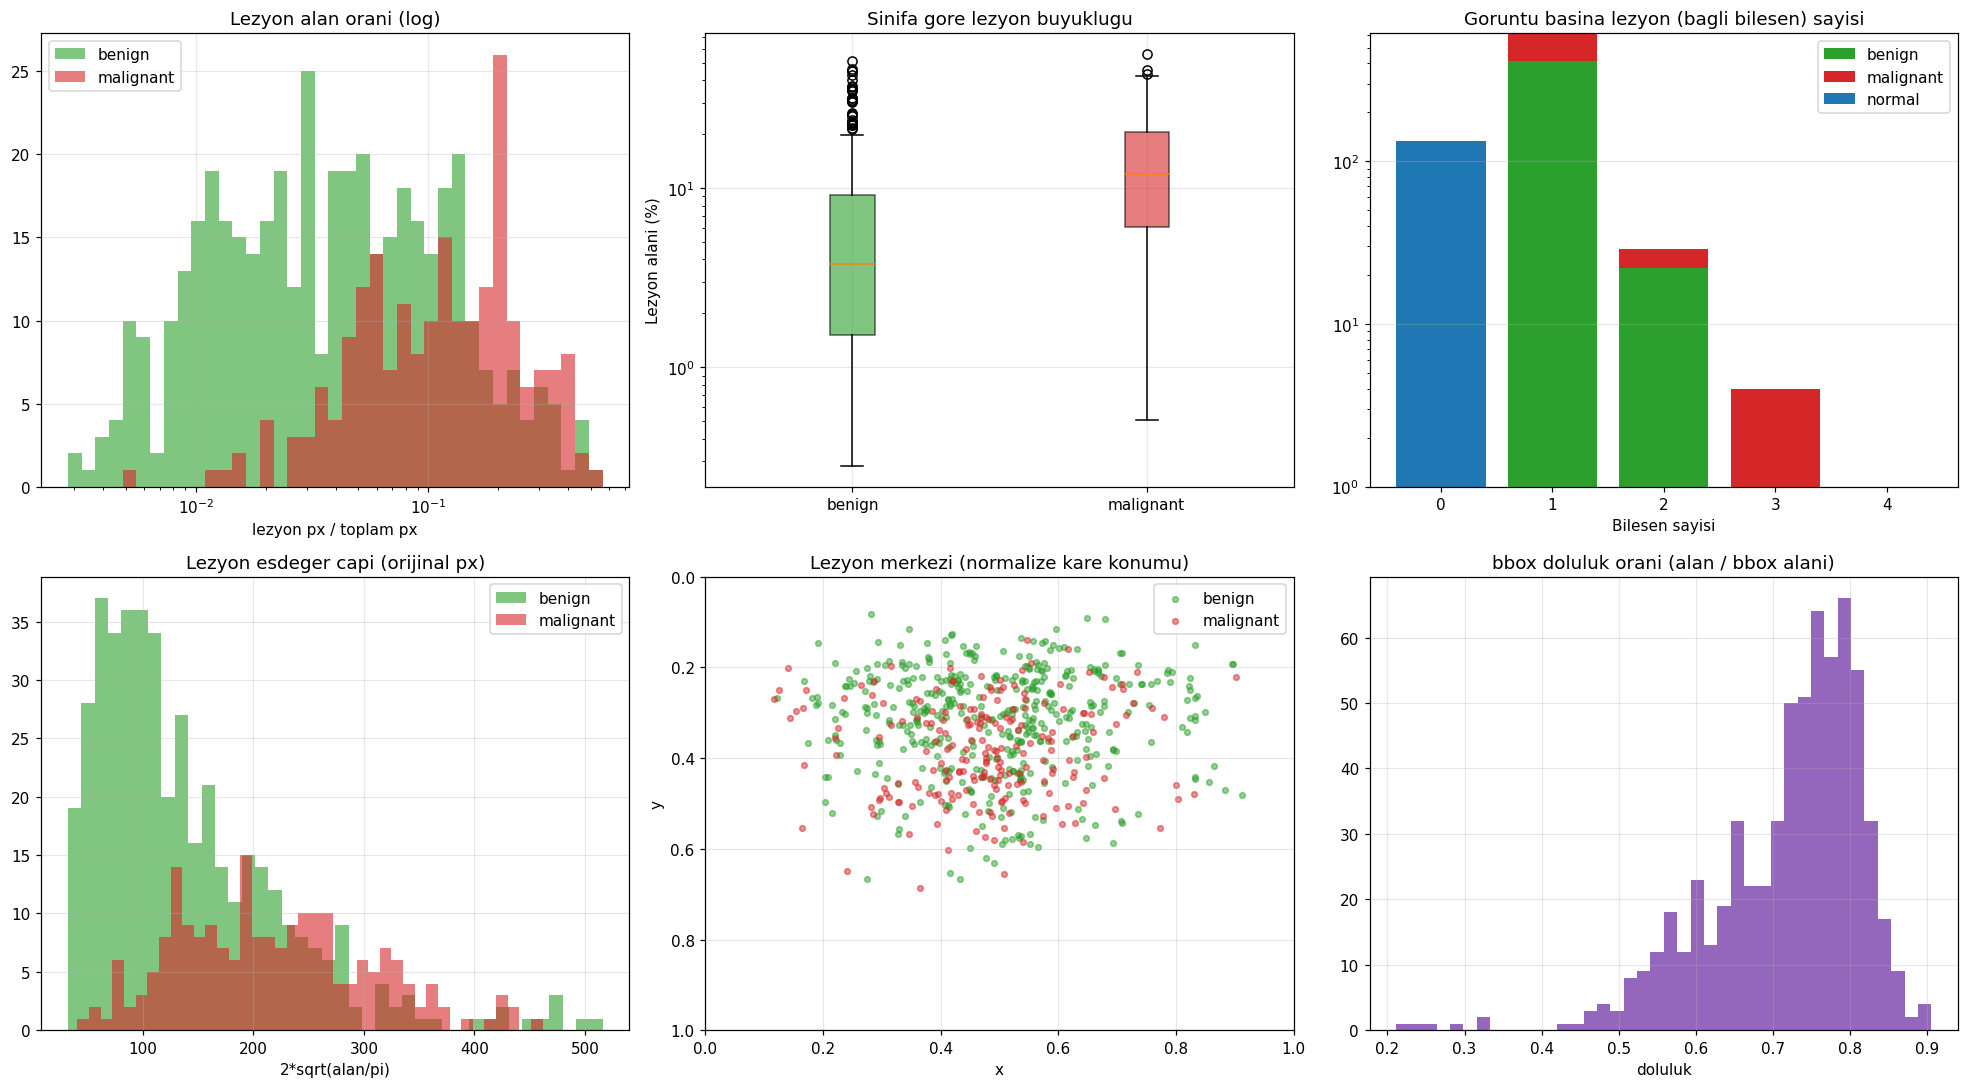

In [6]:
les = df[df['lesion_px'] > 0]
fig, ax = plt.subplots(2, 3, figsize=(18, 10))

bins = np.logspace(np.log10(les['lesion_ratio'].min()), np.log10(les['lesion_ratio'].max()), 40)
for c in ['benign', 'malignant']:
    s = les[les['cls'] == c]
    ax[0, 0].hist(s['lesion_ratio'], bins=bins, alpha=0.6, label=c, color=CLASS_COLORS[c])
ax[0, 0].set_xscale('log')
ax[0, 0].set_title('Lezyon alan orani (log)'); ax[0, 0].set_xlabel('lezyon px / toplam px')
ax[0, 0].legend(); ax[0, 0].grid(alpha=0.3)

data = [les[les['cls'] == c]['lesion_ratio'] * 100 for c in ['benign', 'malignant']]
bp = ax[0, 1].boxplot(data, patch_artist=True)
for patch, c in zip(bp['boxes'], ['benign', 'malignant']):
    patch.set_facecolor(CLASS_COLORS[c]); patch.set_alpha(0.6)
ax[0, 1].set_xticks([1, 2]); ax[0, 1].set_xticklabels(['benign', 'malignant'])
ax[0, 1].set_yscale('log'); ax[0, 1].set_ylabel('Lezyon alani (%)')
ax[0, 1].set_title('Sinifa gore lezyon buyuklugu'); ax[0, 1].grid(alpha=0.3)

ct = pd.crosstab(df['n_components'], df['cls']).reindex(columns=CLASSES, fill_value=0)
bottom = np.zeros(len(ct))
for c in CLASSES:
    ax[0, 2].bar(ct.index, ct[c], bottom=bottom, label=c, color=CLASS_COLORS[c])
    bottom += ct[c].to_numpy()
ax[0, 2].set_title('Goruntu basina lezyon (bagli bilesen) sayisi')
ax[0, 2].set_xlabel('Bilesen sayisi'); ax[0, 2].set_yscale('log')
ax[0, 2].legend(); ax[0, 2].grid(alpha=0.3, axis='y')

for c in ['benign', 'malignant']:
    s = les[les['cls'] == c]
    ax[1, 0].hist(s['eq_diam'], bins=40, alpha=0.6, label=c, color=CLASS_COLORS[c])
ax[1, 0].set_title('Lezyon esdeger capi (orijinal px)')
ax[1, 0].set_xlabel('2*sqrt(alan/pi)'); ax[1, 0].legend(); ax[1, 0].grid(alpha=0.3)

for c in ['benign', 'malignant']:
    s = les[les['cls'] == c]
    ax[1, 1].scatter(s['center_x'], s['center_y'], s=14, alpha=0.5, label=c, color=CLASS_COLORS[c])
ax[1, 1].set_xlim(0, 1); ax[1, 1].set_ylim(1, 0)
ax[1, 1].set_title('Lezyon merkezi (normalize kare konumu)')
ax[1, 1].set_xlabel('x'); ax[1, 1].set_ylabel('y'); ax[1, 1].legend(); ax[1, 1].grid(alpha=0.3)

ax[1, 2].hist(les['bbox_fill'], bins=40, color='tab:purple')
ax[1, 2].set_title('bbox doluluk orani (alan / bbox alani)')
ax[1, 2].set_xlabel('doluluk'); ax[1, 2].grid(alpha=0.3)

plt.tight_layout()
savefig(f'{FIG_DIR}/02_lezyon_morfolojisi.png')
plt.show()

## 5. Yoğunluk ve kontrast

Ultrasonda lezyon tipik olarak hipoekoik (arkaplandan koyu). Kontrast = (lezyon ortalaması − arkaplan ortalaması) / arkaplan std — negatif değerler hipoekoik demek. Bu dağılım, brightness/contrast augmentasyonunun ne kadar agresif olabileceğini sınırlar.

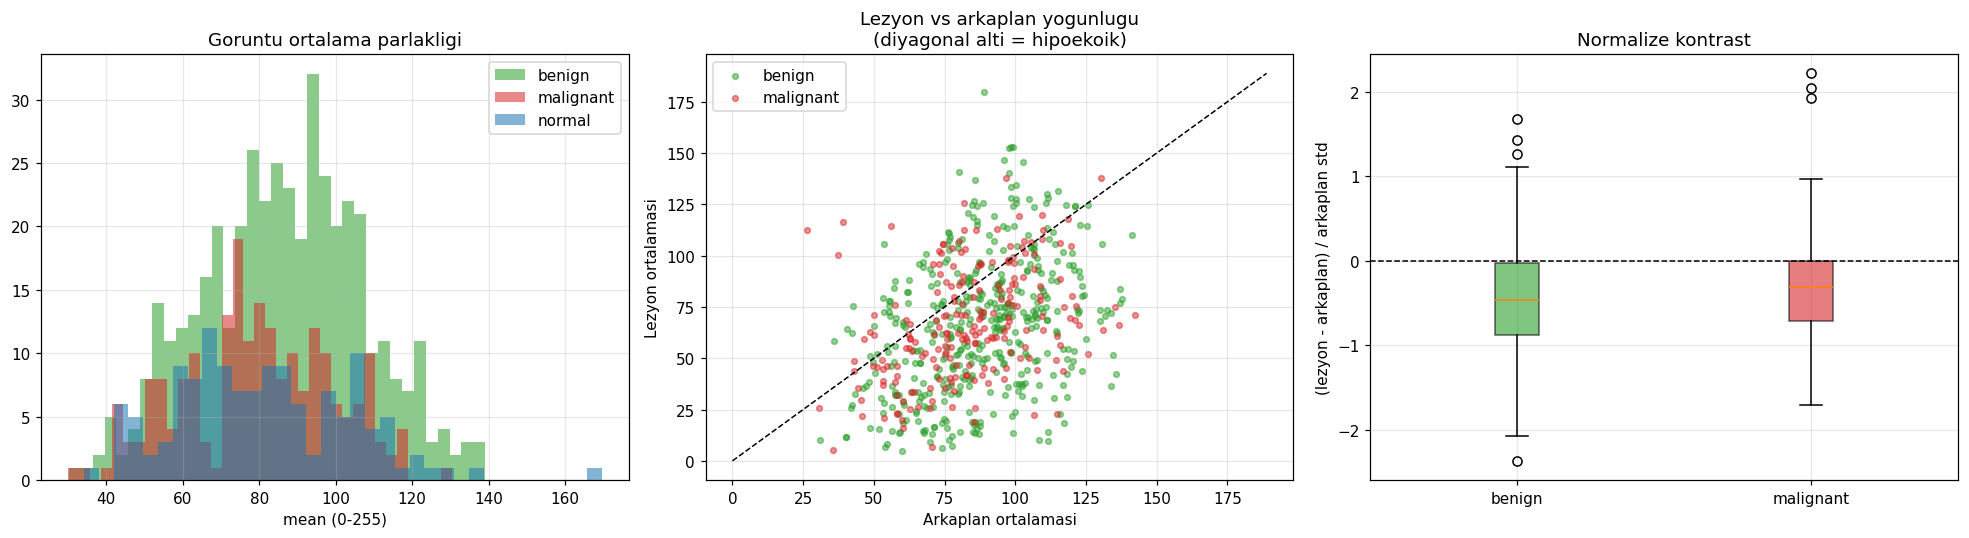

Hipoekoik (kontrast < 0) vaka orani: 75.4%
               mean       50%       min       max
cls                                              
benign    -0.438659 -0.465239 -2.365998  1.679667
malignant -0.313749 -0.305328 -1.709427  2.216557


In [7]:
fig, ax = plt.subplots(1, 3, figsize=(18, 5))

for c in CLASSES:
    s = df[df['cls'] == c]
    ax[0].hist(s['img_mean'], bins=35, alpha=0.55, label=c, color=CLASS_COLORS[c])
ax[0].set_title('Goruntu ortalama parlakligi')
ax[0].set_xlabel('mean (0-255)'); ax[0].legend(); ax[0].grid(alpha=0.3)

for c in ['benign', 'malignant']:
    s = les[les['cls'] == c]
    ax[1].scatter(s['bg_mean'], s['lesion_mean'], s=14, alpha=0.5, label=c, color=CLASS_COLORS[c])
lim = [0, max(les['bg_mean'].max(), les['lesion_mean'].max()) * 1.05]
ax[1].plot(lim, lim, 'k--', lw=1)
ax[1].set_xlabel('Arkaplan ortalamasi'); ax[1].set_ylabel('Lezyon ortalamasi')
ax[1].set_title('Lezyon vs arkaplan yogunlugu\n(diyagonal alti = hipoekoik)')
ax[1].legend(); ax[1].grid(alpha=0.3)

data = [les[les['cls'] == c]['contrast'] for c in ['benign', 'malignant']]
bp = ax[2].boxplot(data, patch_artist=True)
for patch, c in zip(bp['boxes'], ['benign', 'malignant']):
    patch.set_facecolor(CLASS_COLORS[c]); patch.set_alpha(0.6)
ax[2].set_xticks([1, 2]); ax[2].set_xticklabels(['benign', 'malignant'])
ax[2].axhline(0, color='k', ls='--', lw=1)
ax[2].set_title('Normalize kontrast'); ax[2].set_ylabel('(lezyon - arkaplan) / arkaplan std')
ax[2].grid(alpha=0.3)

plt.tight_layout()
savefig(f'{FIG_DIR}/03_yogunluk_kontrast.png')
plt.show()

print('Hipoekoik (kontrast < 0) vaka orani: %.1f%%' % (100 * (les['contrast'] < 0).mean()))
print(les.groupby('cls')['contrast'].describe()[['mean', '50%', 'min', 'max']].to_string())

## 6. Yinelenen / yakın-kopya görüntü tespiti

BUSI'de aynı hastadan alınmış çok benzer kareler ve birebir kopyalar bilinen bir sorun. Bunlar rastgele split'te train ve validation'a dağılırsa metrik şişer — model ezberlediği kareyi tekrar görür.

İki aşamalı tespit:

1. **Aday üretimi** — dHash (64 bit) + Hamming mesafesi ≤ 6. Ucuz, tüm çiftleri tarar.
2. **Teyit** — adayların 128×128 z-normalize küçük kopyaları arasında Pearson korelasyonu + maskelerin IoU'su. dHash tek başına yanıltıcı (ultrason kareleri genel olarak birbirine benzer); korelasyon gerçek kopyayı ayırır.

Ayrıca iki kritik alt küme çıkarılır:

- **Çelişkili etiketli çiftler**: korelasyon yüksek ama maske IoU düşük → aynı görüntü, farklı anotasyon.
- **Kopya grupları**: birleşim-bul (union-find) ile bağlantılı bileşenler. Split bu **grup** birimiyle yapılmalı, görüntü birimiyle değil.

In [8]:
HAMMING_THRESH = 6     # aday esigi (gevsek, teyit ikinci asamada)
CORR_THRESH = 0.95     # kopya sayilma esigi
IOU_CONFLICT = 0.5     # bu esigin altinda etiket celiskisi sayilir

hv = df['dhash'].to_numpy(dtype=object)
bits = np.array([[(int(v) >> k) & 1 for k in range(64)] for v in hv], dtype=np.uint8)
dist = (bits[:, None, :] != bits[None, :, :]).sum(-1)

iu = np.triu_indices(N, k=1)
sel = np.where(dist[iu] <= HAMMING_THRESH)[0]
I, J = iu[0][sel], iu[1][sel]

corr = (thumbs[I] * thumbs[J]).sum(1) / (128 * 128)
inter = np.logical_and(mthumbs[I], mthumbs[J]).sum((1, 2))
union = np.logical_or(mthumbs[I], mthumbs[J]).sum((1, 2))
iou = np.where(union > 0, inter / np.maximum(union, 1), 1.0)   # iki maske de bossa ozdes sayilir

cid = df['case_id'].to_numpy()
ccl = df['cls'].to_numpy()
# i / j satir indisleri kolon olarak tutuluyor: asagida sort_values var ve dis I/J
# dizileri sirali cerceveyle hizasini kaybederdi -> grup kurulumu yanlis ciftleri birlestirirdi
pairs = pd.DataFrame(dict(a=cid[I], b=cid[J], i=I, j=J, cls_a=ccl[I], cls_b=ccl[J],
                          hamming=dist[iu][sel],
                          corr=corr.astype(np.float64), mask_iou=iou.astype(np.float64)))
pairs['ayni_sinif'] = pairs['cls_a'] == pairs['cls_b']
pairs['kopya'] = pairs['corr'] > CORR_THRESH
pairs['etiket_celiskisi'] = pairs['kopya'] & (pairs['mask_iou'] < IOU_CONFLICT)
pairs = pairs.sort_values('corr', ascending=False).reset_index(drop=True)

dup = pairs[pairs['kopya']]
print('dHash adayi (hamming <= %d) : %d' % (HAMMING_THRESH, len(pairs)))
print('Teyitli kopya (corr > %.2f) : %d' % (CORR_THRESH, len(dup)))
print('  etkilenen benzersiz goruntu:', len(set(dup['a']) | set(dup['b'])))
print('  siniflar arasi kopya       :', int((~dup['ayni_sinif']).sum()))
print('  ETIKET CELISKISI (IoU<%.1f):' % IOU_CONFLICT, int(dup['etiket_celiskisi'].sum()))
print()
print('Etiket celiskisi olan ciftler:')
print(dup[dup['etiket_celiskisi']][['a', 'b', 'corr', 'mask_iou']].to_string(
    index=False, float_format=lambda x: f'{x:.3f}'))

PAIRS_XLSX = f'{DRIVE_DIR}/eda_kopya_ciftler.xlsx'
pairs.to_excel(PAIRS_XLSX, index=False)
mirror_to_local(PAIRS_XLSX)

dHash adayi (hamming <= 6) : 196
Teyitli kopya (corr > 0.95) : 115
  etkilenen benzersiz goruntu: 179
  siniflar arasi kopya       : 6
  ETIKET CELISKISI (IoU<0.5): 11

Etiket celiskisi olan ciftler:
                        a                        b  corr  mask_iou
      benign/benign (233)      benign/benign (299) 0.999     0.149
malignant/malignant (116) malignant/malignant (18) 0.998     0.116
      benign/benign (228)      benign/benign (306) 0.992     0.442
      benign/benign (131) malignant/malignant (51) 0.989     0.292
      benign/benign (211)      benign/benign (254) 0.984     0.282
      benign/benign (321)        benign/benign (4) 0.979     0.200
      benign/benign (437)       normal/normal (34) 0.978     0.000
      benign/benign (269)        normal/normal (1) 0.977     0.000
      benign/benign (163)       benign/benign (86) 0.973     0.435
      benign/benign (131)       benign/benign (42) 0.970     0.241
      benign/benign (119)      benign/benign (122) 0.954     0.

'/content/outputs/eda/eda_kopya_ciftler.xlsx'

In [9]:
# Kopya gruplari: split bu grup birimiyle yapilacak, ayni grup asla iki bolume dagilmayacak
def union_find_groups(n, edges):
    parent = list(range(n))

    def find(x):
        while parent[x] != x:
            parent[x] = parent[parent[x]]
            x = parent[x]
        return x

    for i, j in edges:
        ri, rj = find(i), find(j)
        if ri != rj:
            parent[ri] = rj
    return np.array([find(i) for i in range(n)])


# kenarlar pairs'in kendi i/j kolonlarindan aliniyor - sirali cerceveyle hizali kalsin diye
kop = pairs[pairs['kopya']]
raw = union_find_groups(N, list(zip(kop['i'], kop['j'])))
# grup id'lerini 0..K-1 araligina sikistir
uniq = {g: k for k, g in enumerate(sorted(set(raw.tolist())))}
df['group_id'] = [uniq[g] for g in raw]

gsizes = df['group_id'].value_counts()
gruplanan = int(gsizes[gsizes > 1].sum())
print('Toplam grup       :', df['group_id'].nunique(), f'(  {N} goruntu )')
print('Cok goruntulu grup:', int((gsizes > 1).sum()))
print('Gruplanan goruntu :', gruplanan, '(%.1f%%)' % (100 * gruplanan / N))
print('En buyuk grup     :', int(gsizes.max()))
print('Grup boyutu dagilimi:', gsizes.value_counts().sort_index().to_dict())

# tutarlilik: gruplanan goruntu sayisi, kopya ciftlerinin dokundugu goruntu sayisina esit olmali
etkilenen = len(set(kop['a']) | set(kop['b']))
assert gruplanan == etkilenen, f'grup kurulumu tutarsiz: {gruplanan} != {etkilenen}'

# esik duyarliligi: karar verirken hangi esikte ne kadar veri gruplaniyor
print('\nEsik duyarliligi:')
for th in [0.99, 0.97, 0.95, 0.90, 0.85]:
    m = pairs[pairs['corr'] > th]
    g = union_find_groups(N, list(zip(m['i'], m['j'])))
    s = pd.Series(g).value_counts()
    print('  corr>%.2f -> %3d grup, en buyuk %d, gruplanan goruntu %3d (%.1f%%)' % (
        th, len(s), s.max(), int(s[s > 1].sum()), 100 * s[s > 1].sum() / N))

GROUPS_XLSX = f'{DRIVE_DIR}/eda_kopya_gruplari.xlsx'
df[['case_id', 'cls', 'group_id', 'lesion_ratio']].to_excel(GROUPS_XLSX, index=False)
mirror_to_local(GROUPS_XLSX)

print('\nEn buyuk 5 grup:')
for g in gsizes.head(5).index:
    s = df[df['group_id'] == g]
    print(f'  grup {g} ({len(s)}):', ', '.join(f"{r.case_id} [alan %{r.lesion_ratio*100:.1f}]"
                                               for r in s.itertuples()))

Toplam grup       : 681 (  780 goruntu )
Cok goruntulu grup: 80
Gruplanan goruntu : 179 (22.9%)
En buyuk grup     : 4
Grup boyutu dagilimi: {1: 601, 2: 65, 3: 11, 4: 4}

Esik duyarliligi:
  corr>0.99 -> 764 grup, en buyuk 3, gruplanan goruntu  31 (4.0%)
  corr>0.97 -> 709 grup, en buyuk 4, gruplanan goruntu 128 (16.4%)
  corr>0.95 -> 681 grup, en buyuk 4, gruplanan goruntu 179 (22.9%)
  corr>0.90 -> 635 grup, en buyuk 4, gruplanan goruntu 262 (33.6%)
  corr>0.85 -> 624 grup, en buyuk 4, gruplanan goruntu 284 (36.4%)

En buyuk 5 grup:
  grup 643 (4): normal/normal (41) [alan %0.0], normal/normal (44) [alan %0.0], normal/normal (47) [alan %0.0], normal/normal (61) [alan %0.0]
  grup 558 (4): malignant/malignant (6) [alan %6.1], malignant/malignant (7) [alan %5.0], malignant/malignant (8) [alan %5.5], malignant/malignant (9) [alan %5.3]
  grup 648 (4): normal/normal (55) [alan %0.0], normal/normal (57) [alan %0.0], normal/normal (67) [alan %0.0], normal/normal (68) [alan %0.0]
  grup 366 

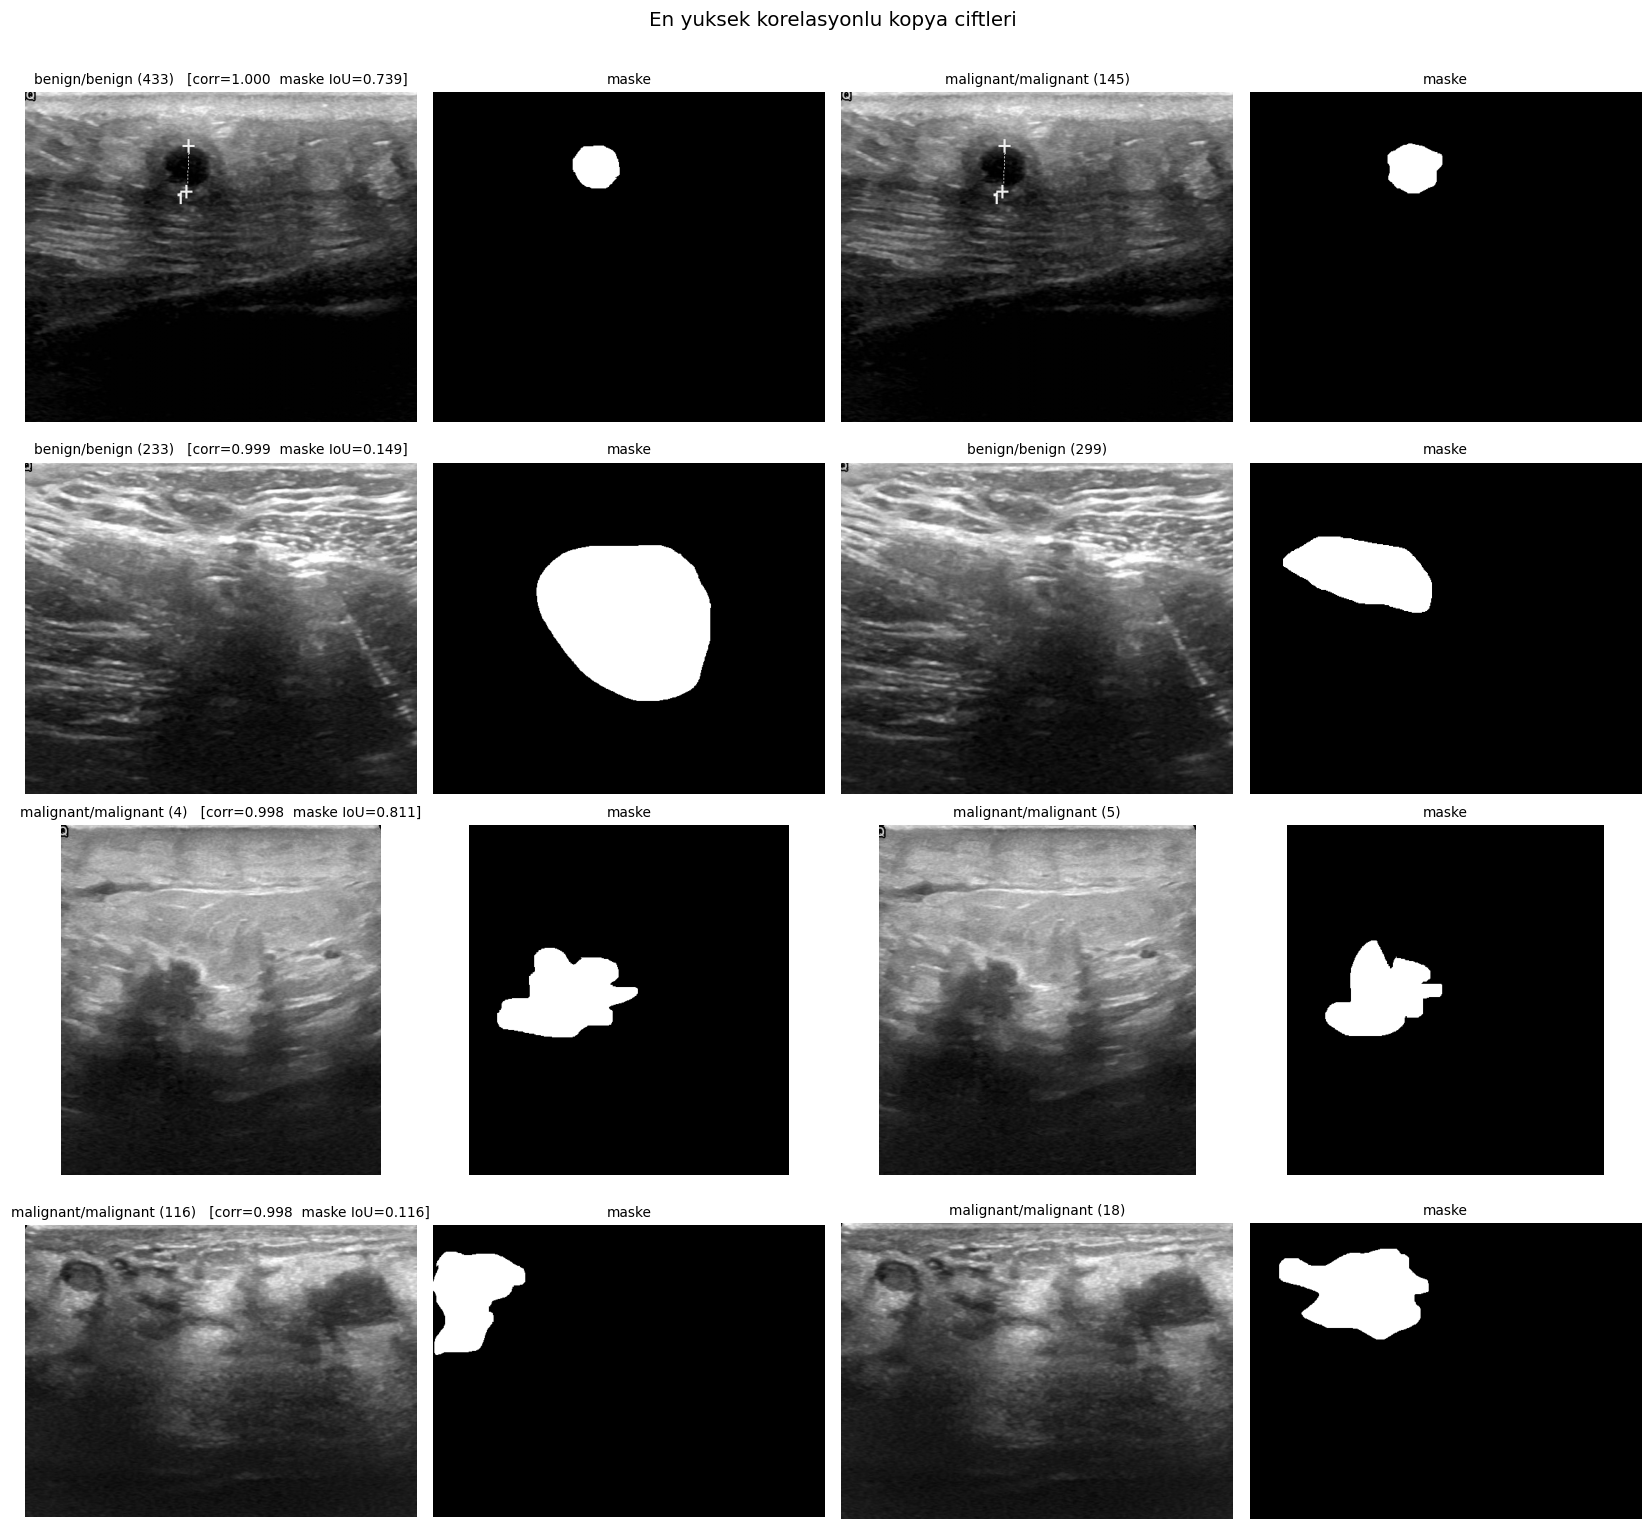

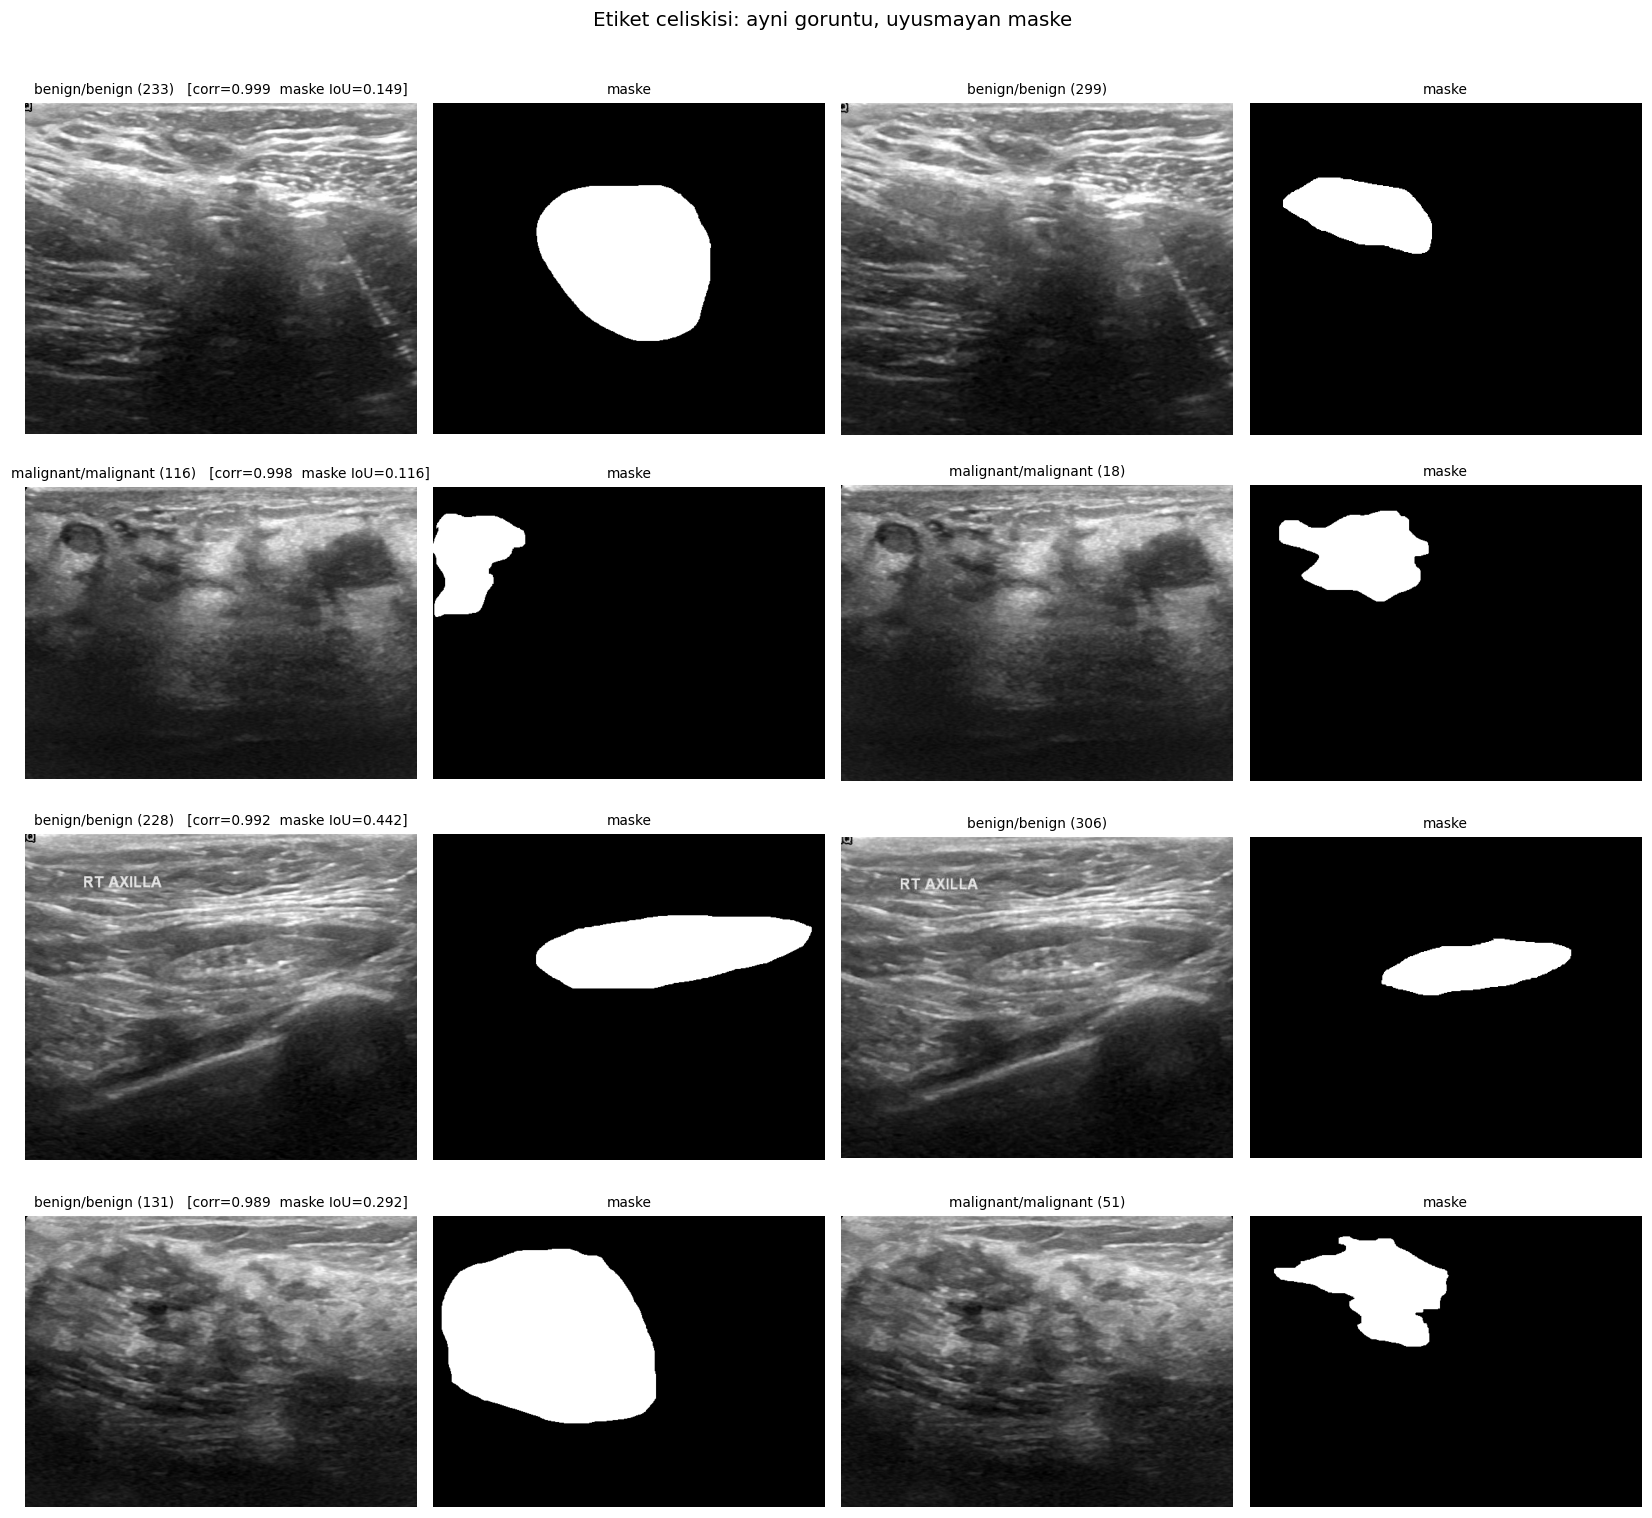

In [10]:
lookup = {c['case_id']: c for c in cases}


def get_pair(case_id):
    c = lookup[case_id]
    img, _ = read_gray(c['image'])
    mask, _, _ = merge_masks(c['masks'], img.shape)
    return img, mask


def plot_pair_rows(sub, title, out_png):
    # her satir: goruntu A | maske A | goruntu B | maske B
    if not len(sub):
        print('Gosterilecek cift yok:', title)
        return
    fig, ax = plt.subplots(len(sub), 4, figsize=(15, 3.6 * len(sub)))
    ax = np.atleast_2d(ax)
    for r, (_, p) in enumerate(sub.iterrows()):
        for k, cidx in enumerate([p['a'], p['b']]):
            img, mask = get_pair(cidx)
            ax[r, 2 * k].imshow(img, cmap='gray')
            ax[r, 2 * k].set_title(cidx, fontsize=9)
            ax[r, 2 * k + 1].imshow(mask, cmap='gray')
            ax[r, 2 * k + 1].set_title('maske', fontsize=9)
        ax[r, 0].set_title(f"{p['a']}   [corr={p['corr']:.3f}  maske IoU={p['mask_iou']:.3f}]", fontsize=9)
        for j in range(4):
            ax[r, j].axis('off')
    plt.suptitle(title, fontsize=13)
    plt.tight_layout(rect=[0, 0, 1, 0.97])
    savefig(out_png)
    plt.show()


plot_pair_rows(dup.head(4), 'En yuksek korelasyonlu kopya ciftleri', f'{FIG_DIR}/04a_kopyalar.png')
plot_pair_rows(dup[dup['etiket_celiskisi']].head(4),
               'Etiket celiskisi: ayni goruntu, uyusmayan maske', f'{FIG_DIR}/04b_etiket_celiskisi.png')

## 7. Gerçek zamanlı girdi çözünürlüğü analizi

Bu proje real-time olduğu için girdi boyutu doğrudan FPS'i belirliyor — ama küçültünce lezyon piksel olarak kayboluyor. Aşağıdaki tablo her hedef boyut için lezyonun kaç piksele indiğini gösteriyor; model seçimi ve `IMAGE_SIZE` kararının sayısal dayanağı bu.

Referans: SegFormer-B0 / YOLOv11-Seg gibi mimarilerde çıktı stride'ı 4; yani girdideki 4 pikselden küçük yapılar maske başlığında tek hücreye bile düşmüyor.

  girdi  medyan_lezyon_px  p5_lezyon_px  min_lezyon_px  medyan_cap_px  p5_cap_px  cap_16px_alti_yuzde  cap_8px_alti_yuzde  stride4_hucre_medyan
192x192              2124           272            103           52.0       18.6                  2.9                 0.0                   132
256x256              3777           483            184           69.4       24.8                  0.2                 0.0                   236
320x320              5902           755            287           86.7       31.0                  0.0                 0.0                   368
384x384              8499          1088            414          104.0       37.2                  0.0                 0.0                   531
512x512             15110          1935            737          138.7       49.6                  0.0                 0.0                   944


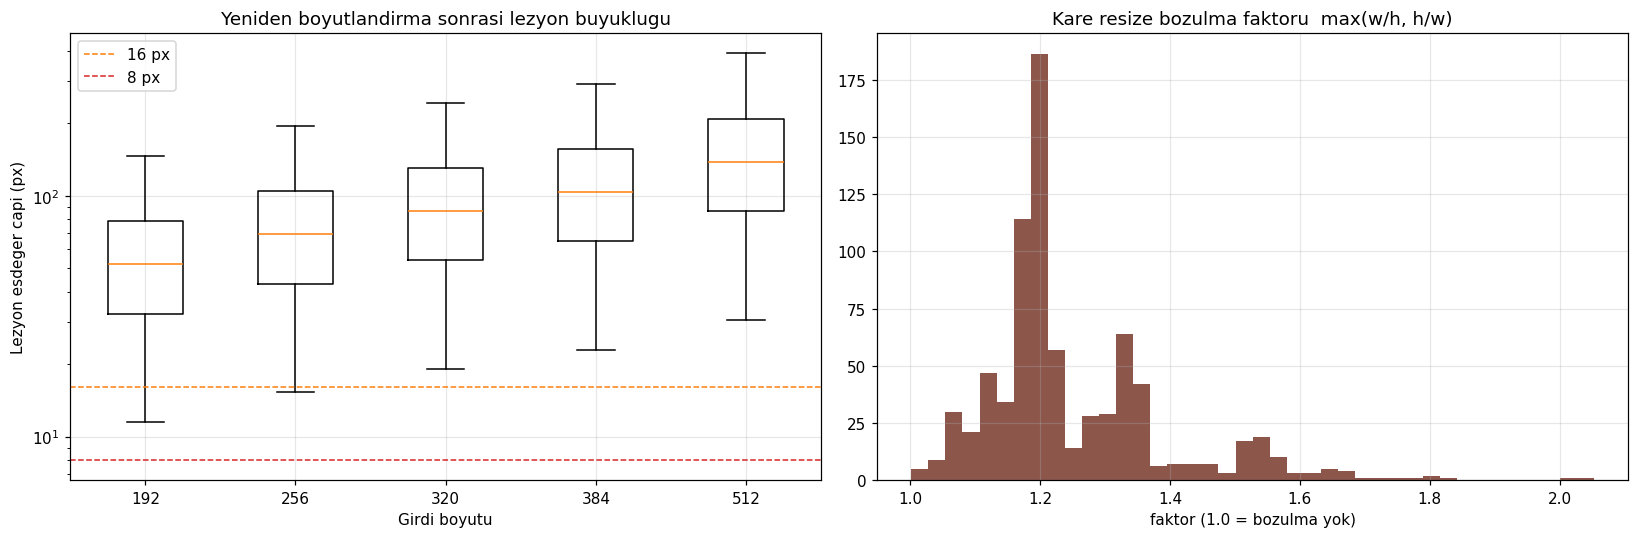

Bozulma faktoru: medyan 1.20, p95 1.54, max 2.05


In [11]:
TARGETS = [192, 256, 320, 384, 512]

rt_rows = []
for S in TARGETS:
    px = les['lesion_ratio'] * S * S           # kare resize alan orani korur
    dia = 2 * np.sqrt(px / np.pi)
    rt_rows.append(dict(
        girdi=f'{S}x{S}',
        medyan_lezyon_px=int(px.median()),
        p5_lezyon_px=int(px.quantile(0.05)),
        min_lezyon_px=int(px.min()),
        medyan_cap_px=round(float(dia.median()), 1),
        p5_cap_px=round(float(dia.quantile(0.05)), 1),
        cap_16px_alti_yuzde=round(float((dia < 16).mean() * 100), 1),
        cap_8px_alti_yuzde=round(float((dia < 8).mean() * 100), 1),
        stride4_hucre_medyan=int(px.median() / 16),
    ))
rt = pd.DataFrame(rt_rows)
print(rt.to_string(index=False))

RT_XLSX = f'{DRIVE_DIR}/eda_cozunurluk_analizi.xlsx'
rt.to_excel(RT_XLSX, index=False)
mirror_to_local(RT_XLSX)

fig, ax = plt.subplots(1, 2, figsize=(15, 5))
data = [2 * np.sqrt((les['lesion_ratio'] * S * S) / np.pi) for S in TARGETS]
ax[0].boxplot(data, showfliers=False)
ax[0].set_xticks(np.arange(1, len(TARGETS) + 1))
ax[0].set_xticklabels([str(s) for s in TARGETS])
ax[0].axhline(16, color='tab:orange', ls='--', lw=1, label='16 px')
ax[0].axhline(8, color='tab:red', ls='--', lw=1, label='8 px')
ax[0].set_yscale('log')
ax[0].set_xlabel('Girdi boyutu'); ax[0].set_ylabel('Lezyon esdeger capi (px)')
ax[0].set_title('Yeniden boyutlandirma sonrasi lezyon buyuklugu')
ax[0].legend(); ax[0].grid(alpha=0.3)

# kare resize en/boy oranini bozuyor: bozulma faktoru dagilimi
distort = np.maximum(df['aspect'], 1 / df['aspect'])
ax[1].hist(distort, bins=40, color='tab:brown')
ax[1].set_title('Kare resize bozulma faktoru  max(w/h, h/w)')
ax[1].set_xlabel('faktor (1.0 = bozulma yok)'); ax[1].grid(alpha=0.3)

plt.tight_layout()
savefig(f'{FIG_DIR}/05_cozunurluk_analizi.png')
plt.show()
print('Bozulma faktoru: medyan %.2f, p95 %.2f, max %.2f' % (
    distort.median(), distort.quantile(0.95), distort.max()))

## 8. Örnek vaka görselleri

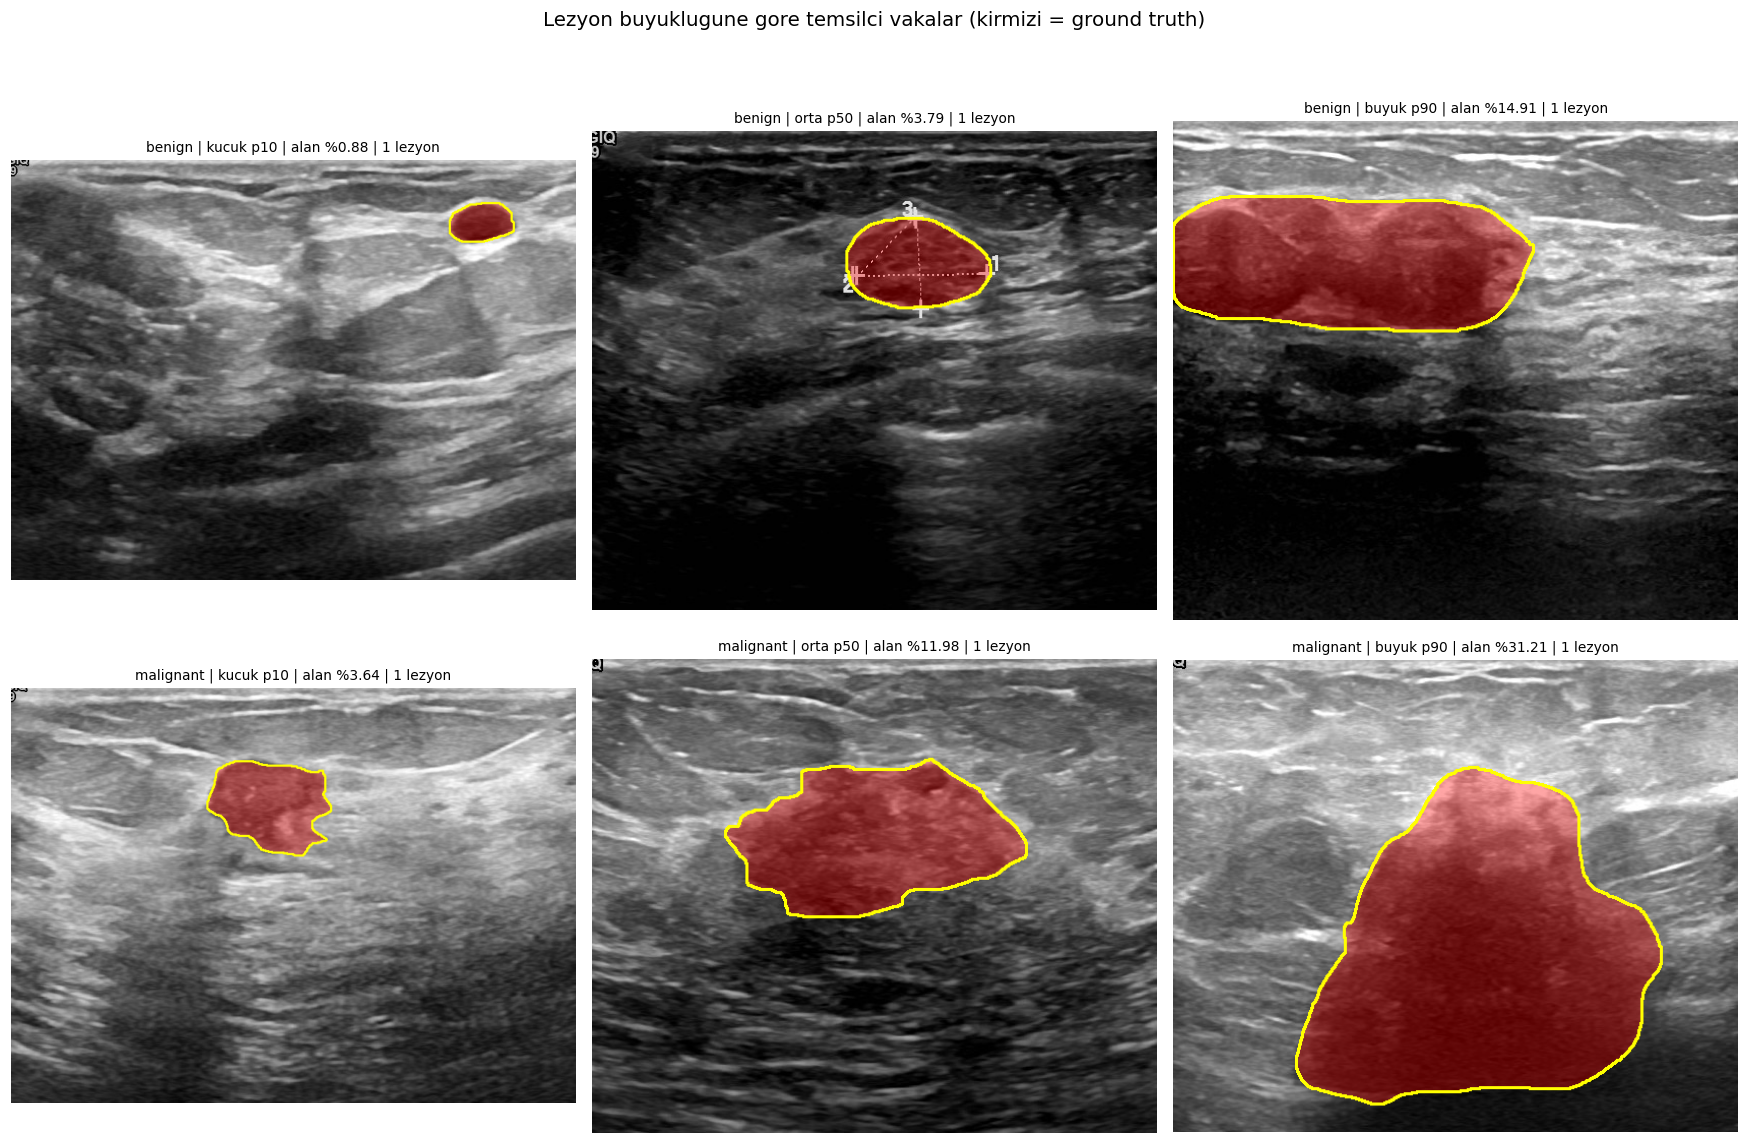

In [12]:
def overlay(img, mask, alpha=0.35):
    rgb = cv2.cvtColor(img, cv2.COLOR_GRAY2RGB).astype(np.float32)
    col = np.zeros_like(rgb); col[..., 0] = 255.0
    a = mask[..., None].astype(np.float32) * alpha
    out = (rgb * (1 - a) + col * a).astype(np.uint8)
    cnts, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    cv2.drawContours(out, cnts, -1, (255, 255, 0), 2)
    return out


# lezyon boyutuna gore p10 / p50 / p90 temsilci vakalar
picks = []
for c in ['benign', 'malignant']:
    s = les[les['cls'] == c].sort_values('lesion_ratio')
    for qq, name in [(0.10, 'kucuk p10'), (0.50, 'orta p50'), (0.90, 'buyuk p90')]:
        r = s.iloc[int(qq * (len(s) - 1))]
        picks.append((r['case_id'], f"{c} | {name} | alan %{r['lesion_ratio']*100:.2f} | {r['n_components']} lezyon"))

fig, ax = plt.subplots(2, 3, figsize=(16, 11))
for a, (cidx, title) in zip(ax.flatten(), picks):
    img, mask = get_pair(cidx)
    a.imshow(overlay(img, mask))
    a.set_title(title, fontsize=9); a.axis('off')
plt.suptitle('Lezyon buyuklugune gore temsilci vakalar (kirmizi = ground truth)', fontsize=13)
plt.tight_layout(rect=[0, 0, 1, 0.96])
savefig(f'{FIG_DIR}/06_temsilci_vakalar.png')
plt.show()

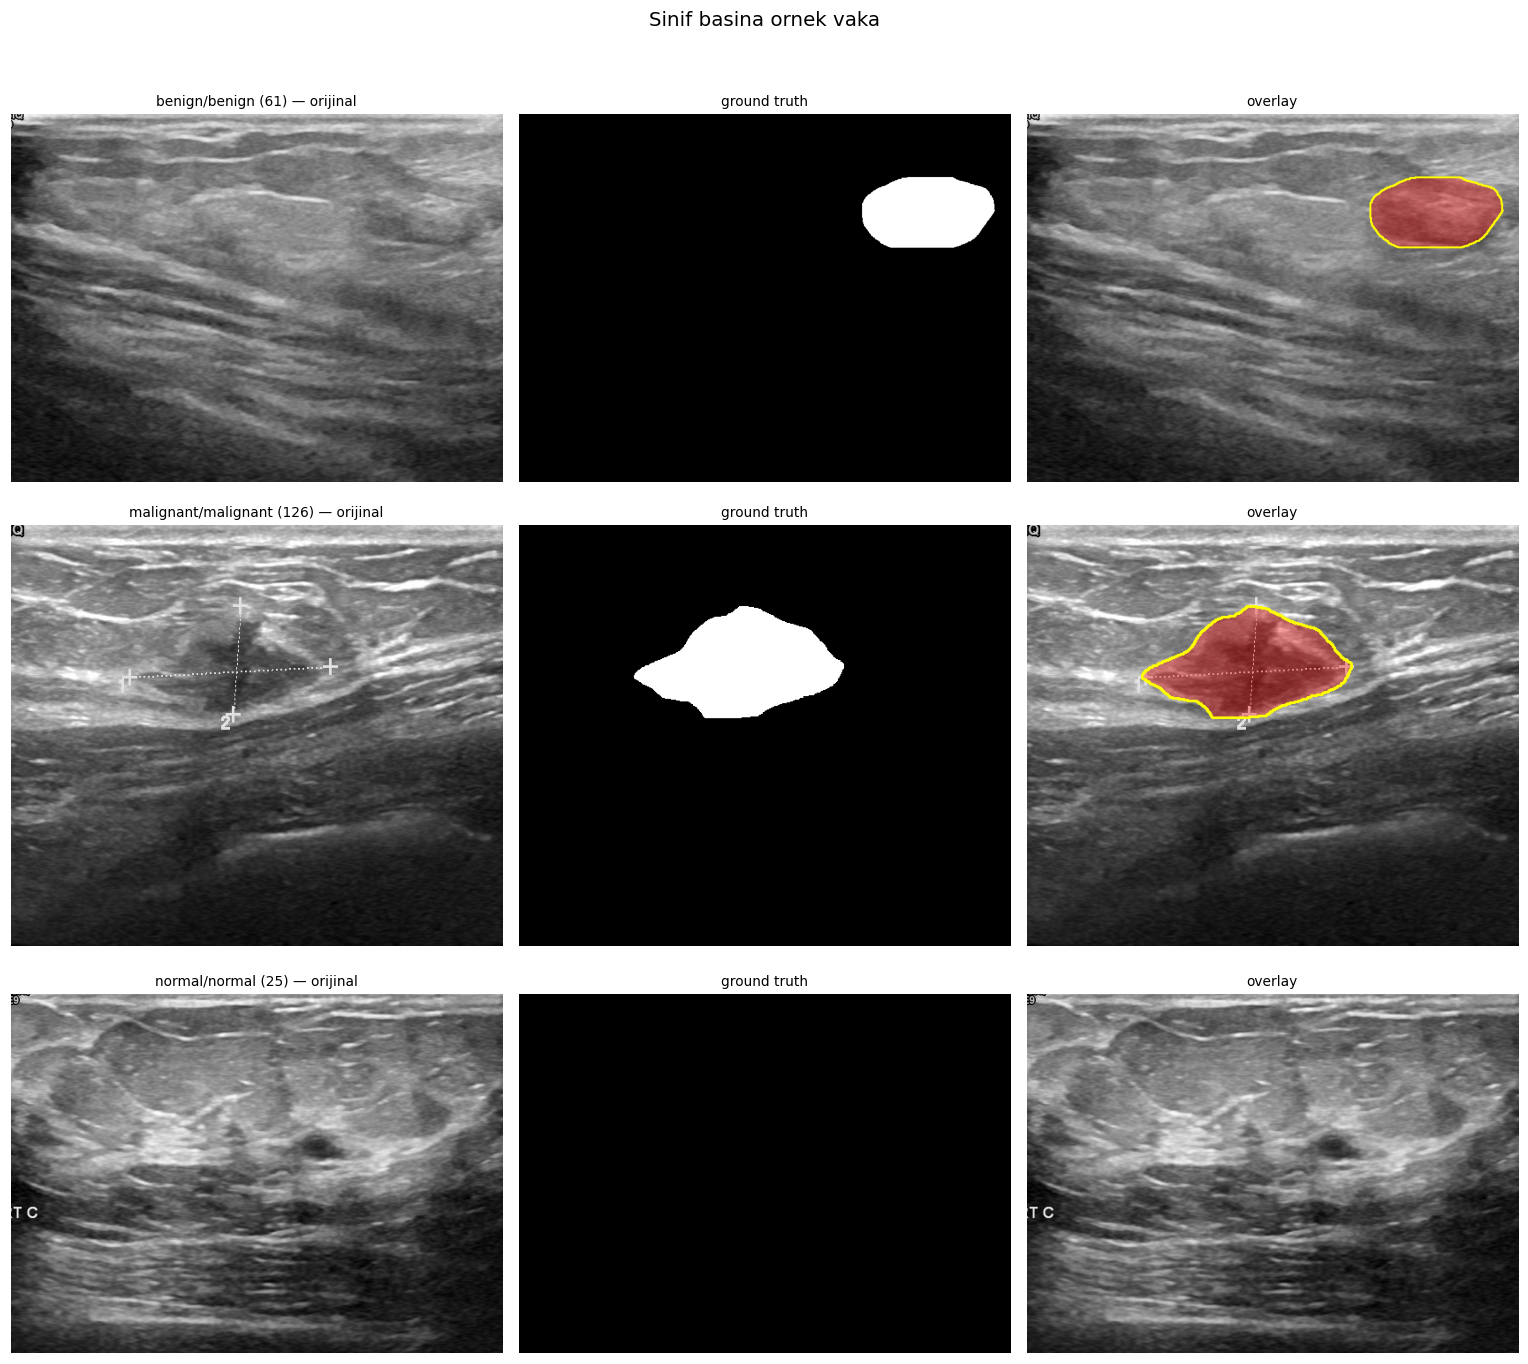

In [13]:
# her siniftan bir vaka: orijinal | ground truth | overlay
rng = np.random.RandomState(SEED)
sample_ids = [df[df['cls'] == c].sample(1, random_state=SEED)['case_id'].iloc[0] for c in CLASSES]

fig, ax = plt.subplots(3, 3, figsize=(14, 13))
for i, cid in enumerate(sample_ids):
    img, mask = get_pair(cid)
    ax[i, 0].imshow(img, cmap='gray'); ax[i, 0].set_title(f'{cid} — orijinal', fontsize=9)
    ax[i, 1].imshow(mask, cmap='gray'); ax[i, 1].set_title('ground truth', fontsize=9)
    ax[i, 2].imshow(overlay(img, mask)); ax[i, 2].set_title('overlay', fontsize=9)
    for j in range(3):
        ax[i, j].axis('off')
plt.suptitle('Sinif basina ornek vaka', fontsize=13)
plt.tight_layout(rect=[0, 0, 1, 0.97])
savefig(f'{FIG_DIR}/07_sinif_ornekleri.png')
plt.show()

## 9. Özet rapor

Tüm bulgular tek markdown dosyasına yazılır (`eda_ozet_raporu.md`); augmentasyon ve split kararları bu tablodan verilecek.

In [14]:
def qtl(s, p):
    return float(np.quantile(s, p))


def md_table(frame):
    # tabulate bagimliligi olmadan markdown tablo
    cols = list(frame.columns)
    out = ['| ' + ' | '.join(cols) + ' |', '|' + '---|' * len(cols)]
    for _, r in frame.iterrows():
        out.append('| ' + ' | '.join(str(r[c]) for c in cols) + ' |')
    return '\n'.join(out)


gsizes = df['group_id'].value_counts()
lines = []
lines.append('# BUSI Veri Analizi — Ozet Rapor\n')
lines.append(f'Toplam vaka: **{len(df)}**  |  benign {int((df.cls=="benign").sum())}, '
             f'malignant {int((df.cls=="malignant").sum())}, normal {int((df.cls=="normal").sum())}\n')

lines.append('\n## Dosya butunlugu\n')
lines.append(f'- Coklu maske dosyasi olan vaka: {int((df.n_mask_files>1).sum())} (birlesim ile tek maskeye indirgendi)')
lines.append(f'- Maske-goruntu boyutu uyusmayan: {int(df.mask_resized.sum())}')
lines.append(f'- Bos maskeli vaka: {int((df.lesion_px==0).sum())}')
lines.append(f'- Anomali (eslesmeyen dosya): {len(anomalies)}')
lines.append(f'- Kanal dagilimi: {df.channels.value_counts().to_dict()}')
lines.append(f'- Maske deger setleri: {df.mask_vals.value_counts().to_dict()}')

lines.append('\n## Cozunurluk\n')
lines.append(f'- Yukseklik: min {int(df.height.min())}, medyan {int(df.height.median())}, max {int(df.height.max())}')
lines.append(f'- Genislik : min {int(df.width.min())}, medyan {int(df.width.median())}, max {int(df.width.max())}')
lines.append(f'- Benzersiz cozunurluk sayisi: {df.groupby(["height","width"]).ngroups}')
lines.append(f'- Kare resize bozulma faktoru: medyan {distort.median():.2f}, p95 {distort.quantile(0.95):.2f}, max {distort.max():.2f}')

lines.append('\n## Lezyon morfolojisi (lezyonlu vakalar)\n')
lines.append('| Sinif | n | Alan % p5 | Alan % medyan | Alan % p95 | Esdeger cap medyan (px) | Cok lezyonlu |')
lines.append('|---|---|---|---|---|---|---|')
for c in ['benign', 'malignant']:
    s = les[les.cls == c]
    lines.append(f'| {c} | {len(s)} | {qtl(s.lesion_ratio,0.05)*100:.2f} | {s.lesion_ratio.median()*100:.2f} | '
                 f'{qtl(s.lesion_ratio,0.95)*100:.2f} | {s.eq_diam.median():.0f} | {int((s.n_components>1).sum())} |')

lines.append('\n## Kontrast\n')
lines.append(f'- Hipoekoik (kontrast<0) vaka orani: %{100*(les.contrast<0).mean():.1f}')
lines.append(f'- Kontrast medyani: benign {les[les.cls=="benign"].contrast.median():.2f}, '
             f'malignant {les[les.cls=="malignant"].contrast.median():.2f}')
lines.append(f'- Goruntu ortalama parlakligi: {df.img_mean.min():.0f} - {df.img_mean.max():.0f} '
             f'(medyan {df.img_mean.median():.0f})')

lines.append('\n## Kopya / yinelenen goruntuler\n')
lines.append(f'- dHash adayi (hamming<={HAMMING_THRESH}): {len(pairs)}')
lines.append(f'- Teyitli kopya cifti (corr>{CORR_THRESH}): {len(dup)}')
lines.append(f'- Etkilenen benzersiz goruntu: {len(set(dup.a)|set(dup.b))} '
             f'(%{100*len(set(dup.a)|set(dup.b))/len(df):.1f})')
lines.append(f'- Siniflar arasi kopya: {int((~dup.ayni_sinif).sum())}')
lines.append(f'- **Etiket celiskisi** (corr yuksek, maske IoU<{IOU_CONFLICT}): {int(dup.etiket_celiskisi.sum())}')
lines.append(f'- Kopya grubu sayisi: {df.group_id.nunique()}, en buyuk grup {int(gsizes.max())}, '
             f'gruplanan goruntu {int(gsizes[gsizes>1].sum())}')
lines.append('\n> Split **grup birimiyle** yapilmali; ayni grup train ve val/test arasinda bolunemez.\n')
lines.append('\nEtiket celiskisi olan ciftler:\n')
lines.append(md_table(dup[dup['etiket_celiskisi']][['a', 'b', 'corr', 'mask_iou']].round(3)))

lines.append('\n## Gercek zamanli cozunurluk analizi\n')
lines.append(md_table(rt))

report = '\n'.join(lines)
REPORT_MD = f'{DRIVE_DIR}/eda_ozet_raporu.md'
Path(REPORT_MD).write_text(report, encoding='utf-8')
mirror_to_local(REPORT_MD)
print(report)

# BUSI Veri Analizi — Ozet Rapor

Toplam vaka: **780**  |  benign 437, malignant 210, normal 133


## Dosya butunlugu

- Coklu maske dosyasi olan vaka: 17 (birlesim ile tek maskeye indirgendi)
- Maske-goruntu boyutu uyusmayan: 0
- Bos maskeli vaka: 133
- Anomali (eslesmeyen dosya): 0
- Kanal dagilimi: {3: 780}
- Maske deger setleri: {'[0, 255]': 647, '[0]': 133}

## Cozunurluk

- Yukseklik: min 310, medyan 474, max 719
- Genislik : min 190, medyan 564, max 1048
- Benzersiz cozunurluk sayisi: 639
- Kare resize bozulma faktoru: medyan 1.20, p95 1.54, max 2.05

## Lezyon morfolojisi (lezyonlu vakalar)

| Sinif | n | Alan % p5 | Alan % medyan | Alan % p95 | Esdeger cap medyan (px) | Cok lezyonlu |
|---|---|---|---|---|---|---|
| benign | 437 | 0.60 | 3.79 | 23.65 | 115 | 24 |
| malignant | 210 | 2.81 | 12.06 | 37.20 | 209 | 10 |

## Kontrast

- Hipoekoik (kontrast<0) vaka orani: %75.4
- Kontrast medyani: benign -0.47, malignant -0.31
- Goruntu ortalama parlakligi: 30 - 170 (medyan 83)

## 